In [102]:
import numpy as np

def housData():
    data = np.loadtxt("houses.txt", delimiter=',')
    X = data[:, :4]
    y = data[:, 4]
    return X, y


X_train, y_train = housData()

In [ ]:
import copy, math
import numpy as np
import matplotlib.pyplot as plt

# X_train = np.array([[2104, 5, 1, 45], [1416, 3, 2, 40], [852, 2, 1, 35]])
# y_train = np.array([460, 232, 178])

b_init = 0
w_init = np.array([  0,0,0,0])
#b_init = 785.1811367994083
#w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])

alpha = 0.9
iterations = 1000


In [104]:
#Cal the Cost:
def predictCost(X,Y,W,B):
    m=X.shape[0]
    totalCost=0
    for i in range(m):
        y_hat=((np.dot(X[i],W))+B)
        #print(f"({X[i]} * {W}) + {B}")
        fwb=y_hat
        err=(fwb-Y[i])**2
        totalCost=totalCost+err
        #print(f"Predicted Cost y^ for House X{i}: {y_hat}     ERROR RATE:{err}")
    
    totalCost=totalCost/(2*m)
    #print(f"Total COst: {totalCost}")
    return totalCost        

In [105]:
def gradientDescent(alpha,X,Y,W,B,iterations):
    
    m,n=X.shape
    J_history = []
    for it in range(iterations):
        #print(f"======GRADIENT ITERATION: {it}===========")
        djdw=np.zeros((m,))
        djdb=0
        w_temp=np.copy(W)
        c=0
        for j in range( n):
            for i in range(m):
                y_hat=((np.dot(X[i],W))+B)
                sqErr=(y_hat-Y[i])**2
                if it % 100 == 0 and c<=25:
                    print(f"Predicted Cost y^ for House X{i}: {y_hat} || OG cost {y_train[i]}")
                    c=c+1
                err=y_hat-Y[i]
                if j==0:
                    djdb=djdb+err
                djdw[i]=err*X[i,j]
            sum=np.sum(djdw)
            w_temp[j]=w_temp[j] - alpha * (sum/m)
            
        W=np.copy(w_temp)
        B=B-alpha * (djdb/m)

        current_cost = predictCost(X, Y, W, B)
        J_history.append(current_cost)
        c=0
        if it % 100 == 0:
            print(f"Iteration {it} | Cost: {current_cost:.2f}")
            print(f"Updated wieghts: {W}")
            print(f"Updated bias: {B}")
    return W, B, J_history


#gradientDescent(alpha,X_train,y_train,w_init,b_init)

In [106]:
#normalisation
def zscoreNorm(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma


XtrainScaled, mu, sigma = zscoreNorm(X_train)
#print(XtrainScaled)

In [107]:
#predictCost(X_train,y_train,w_init,b_init)
#w_final,b_final,J_hist= gradientDescent(alpha,X_train,y_train,w_init,b_init,1000)
w_final,b_final,J_hist= gradientDescent(alpha,XtrainScaled,y_train,w_init,b_init,iterations)
#predictCost(X_train,y_train,w_init,b_init)


Predicted Cost y^ for House X0: 0.0 || OG cost 271.5
Predicted Cost y^ for House X1: 0.0 || OG cost 300.0
Predicted Cost y^ for House X2: 0.0 || OG cost 509.8
Predicted Cost y^ for House X3: 0.0 || OG cost 394.0
Predicted Cost y^ for House X4: 0.0 || OG cost 540.0
Predicted Cost y^ for House X5: 0.0 || OG cost 415.0
Predicted Cost y^ for House X6: 0.0 || OG cost 230.0
Predicted Cost y^ for House X7: 0.0 || OG cost 560.0
Predicted Cost y^ for House X8: 0.0 || OG cost 294.0
Predicted Cost y^ for House X9: 0.0 || OG cost 718.2
Predicted Cost y^ for House X10: 0.0 || OG cost 200.0
Predicted Cost y^ for House X11: 0.0 || OG cost 302.0
Predicted Cost y^ for House X12: 0.0 || OG cost 468.0
Predicted Cost y^ for House X13: 0.0 || OG cost 374.2
Predicted Cost y^ for House X14: 0.0 || OG cost 388.0
Predicted Cost y^ for House X15: 0.0 || OG cost 282.0
Predicted Cost y^ for House X16: 0.0 || OG cost 311.8
Predicted Cost y^ for House X17: 0.0 || OG cost 401.0
Predicted Cost y^ for House X18: 0.0 |

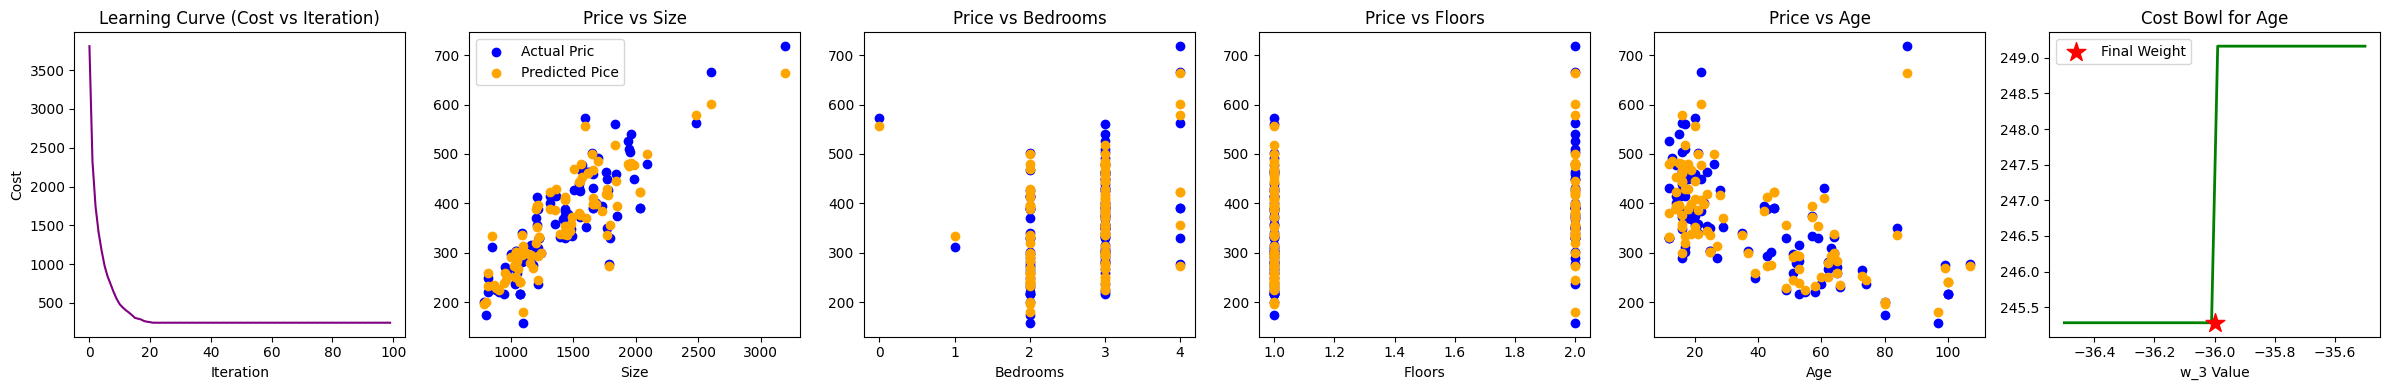

In [108]:
fig, ax = plt.subplots(1, 6, figsize=(24, 4)) 

ax[0].plot(J_hist, color='purple')
ax[0].set_title("Learning Curve (Cost vs Iteration)")
ax[0].set_ylabel("Cost")
ax[0].set_xlabel("Iteration")

featureNames = ["Size", "Bedrooms", "Floors", "Age"]
predictions = np.dot(XtrainScaled, w_final) + b_final

for i in range(4): 
    ax[i+1].scatter(X_train[:, i], y_train, color='blue', label='Actual Pric')
    ax[i+1].scatter(X_train[:, i], predictions, color='orange', label='Predicted Pice')
    ax[i+1].set_title(f"Price vs {featureNames[i]}")
    ax[i+1].set_xlabel(featureNames[i])
    if i == 0: ax[i+1].legend()

weightToCheck = 3
w_center = w_final[weightToCheck]
w_range = np.linspace(w_center - 0.5, w_center + 0.5, 50) 
costs = []

for w_test_val in w_range:
    w_test = np.copy(w_final)
    w_test[weightToCheck] = w_test_val 
    cost_test = predictCost(XtrainScaled, y_train, w_test, b_final) 
    costs.append(cost_test)

ax[5].plot(w_range, costs, color='green', linewidth=2)
ax[5].scatter(w_center, J_hist[-1], color='red', marker='*', s=200, label='Final Weight', zorder=5)
ax[5].set_title(f"Cost Bowl for {featureNames[weightToCheck]}")
ax[5].set_xlabel(f"w_{weightToCheck} Value")
ax[5].legend()

plt.tight_layout()
plt.show()

In [109]:
#Gradient Descent:

alpha = 5.0e-7
w_temp = np.copy(w_init)
#print(f"temp:  {w_temp}")
m,n=X_train.shape
djdw=np.zeros((m,)) # better to write with double parenthesis n,
djdb=0
print(djdw)
err=0

for j in range(n):
    for i in range(m):
        err=(np.dot(w_init ,X_train[i])+b_init)-y_train[i]
        if j==0:
            djdb=djdb+err
        err=err*X_train[i,j]
        djdw[i]=err
    w_sum=np.sum(djdw)
    w_temp[j]=w_temp[j]-alpha*(w_sum/m) 

b_init=b_init-alpha*(djdb/m)    
w_init=np.copy(w_temp)
    


[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
